# 실습 - ADF | 태양 흑점 데이터 분석

In [1]:
# 기본 라이브러리 임포트
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 시각화 세팅 
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [16,4]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("모든 라이브러리 임포트 완료입니다")

모든 라이브러리 임포트 완료입니다


In [ ]:
df = pd.read_csv("data/sunspots.csv", skiprows=0, index_col=0)
df.head()

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7


In [ ]:
df.info()
# 날짜 데이터가 일반 str -> datetime으로 변환

<class 'pandas.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 2 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               3265 non-null   str    
 1   Monthly Mean Total Sunspot Number  3265 non-null   float64
dtypes: float64(1), str(1)
memory usage: 51.1 KB


In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 2 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               3265 non-null   datetime64[us]
 1   Monthly Mean Total Sunspot Number  3265 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 51.1 KB


In [ ]:
# datetime 을 인덱스로 
df.set_index('Date',inplace=True)

In [ ]:
df.info()
# 인덱스가 데이트타임으로 변환 
##  1749-01-31 to 2021-01-31 : 매월 데이터

<class 'pandas.DataFrame'>
DatetimeIndex: 3265 entries, 1749-01-31 to 2021-01-31
Data columns (total 1 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Monthly Mean Total Sunspot Number  3265 non-null   float64
dtypes: float64(1)
memory usage: 51.0 KB


asfreq() 함수를 사용해서 시계열 데이터의 빈도 조정하기
- 시계열 : 일정한 간격이 있어야하고 이걸 빈도라고 함.
- 일별로 측정된 데이터와 월별로 측정된 데이터는 서로 다른 빈도
- 월별 측정된 데이터이니 월별 빈도로 변환 

In [15]:
df.columns

Index(['Monthly Mean Total Sunspot Number'], dtype='str')

In [ ]:
series = df['Monthly Mean Total Sunspot Number'].asfreq('ME')
series # 월단위로 되어 있음을 확인 

Date
1749-01-31     96.7
1749-02-28    104.3
1749-03-31    116.7
1749-04-30     92.8
1749-05-31    141.7
              ...  
2020-09-30      0.6
2020-10-31     14.4
2020-11-30     34.0
2020-12-31     21.8
2021-01-31     10.4
Freq: ME, Name: Monthly Mean Total Sunspot Number, Length: 3265, dtype: float64

<Axes: xlabel='Date'>

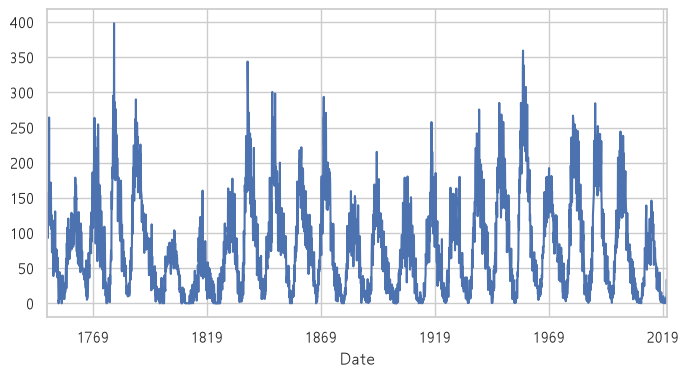

In [18]:
series.plot(figsize = (8,4))

<Axes: xlabel='Date'>

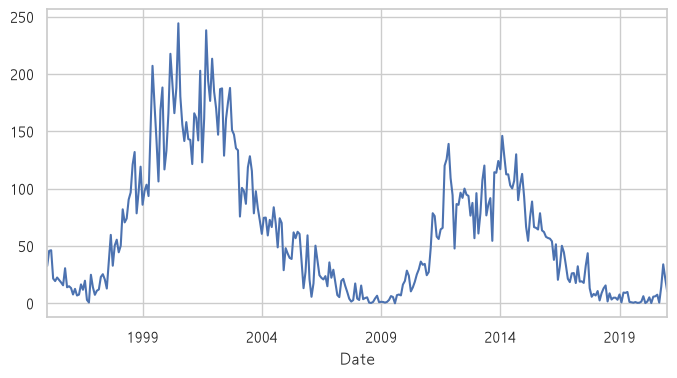

In [21]:
# 1995년도 이후만 확인하기
series['1995-01-01':].plot(figsize = (8,4))

Text(0.5, 1.0, '자기상관성 plot')

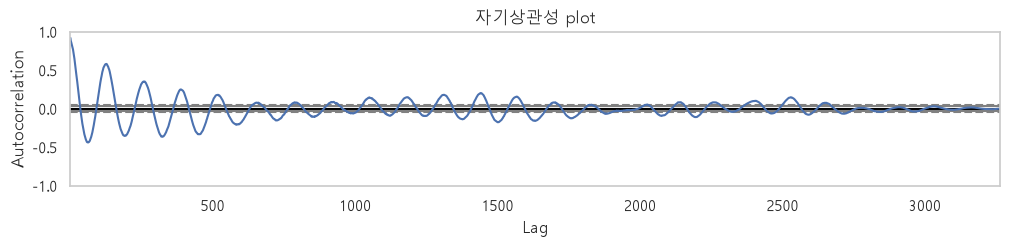

In [23]:
# 자기 상관성을 확인: autocorr plot
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12,2))
autocorrelation_plot(series)
plt.title("자기상관성 plot")

해석 : 
처음에는 큰 자기 상관성을 보이고, 이후에는 자기상관성이 작아짐(신뢰 구간에 근접 : 판단이 어려움 ). 육안으로 확인하기 어려운 상황이 됨.
**이럴 때 Augmented dickey fuller(adf)검정을 사용함.**

ADF 검정 : 시계열 데이터가 정상성을 가지는지 여부를 판단하는 통계적 검정 방법.
- 시계열 데이터의 특징: 
  - 시간에 따라 평균과 분산 일정
  - 시간에 따른 추세나 계절성 X 
  - 고정된 매개변수 = 즉 데이터 생성에 영향을 주는 매개변수가 일정하다. 
  -  보통 정규분포 ( 평균:0, 분산1)이면 굿.

따라서 ADF의 가설은 다음과 같음
- 귀무가설 : 시계열 데이터는 비정상성을 가진다
- 대립가설 : 정상성을 가진다

귀무가설을 기각할 수 있다면 대립가설을 채택할 수 있음.

귀무가설의 주체 :  비정상성을 가질 확률이 0.05(5%)보다 크면 리젝할 수 없음 . 즉 비정상 시계열 데이터이다.
즉 P-VALUE = 비정상성을 가질 확률이고. 이게 0.05보다 크다면 해당 데이터는 정상데이터로 보기 힘들다 = 비정상이다.

결론적으로 
P-VALUE 가 0.05보다 작아야 정상 시계열 데이터이다




# ADF 실습

반환 값 : adf,p-vlaue, critical values

- 정상


In [24]:
# ADF용 라이브러리 불러오기 
## tsa : Time Series analysis
from statsmodels.tsa.stattools import adfuller

In [ ]:
# 정상성 확인하는 함수 만들기
def check_for_stationarity(X, cutoff=0.05):
    pvalue = adfuller(X)[1] #pvalue
    if pvalue < cutoff:
        print(f"p-value: {str(pvalue)}, 해당 시리즈 {X.name}은 정상성 시계열 데이터로 보임. ")
        return True
    else:
        print(f"p-value: {str(pvalue)}, 해당 시리즈 {X.name}은 비정상성 시계열 데이터로 보임.")
        return False

In [26]:
check_for_stationarity(series)

p-value: 1.1085524921956106e-18, 해당 시리즈 Monthly Mean Total Sunspot Number은 정상성 시계열 데이터로 보임. 


True

In [27]:
# 정상 비정상 비교하기
# 평균(mu)하고 표준편차(sigma) 맞춰서 시리즈 만들기
def generate_datapoint(params): # 튜플 형태로 (평균, 분산)
    mu = params[0]
    sigma = params[1]
    return np.random.normal(mu,sigma)

In [34]:
# 정상성 데이터 : seriesA
# 평균이 0이고 표준편차가 1
# 총 100개 시간statmp
params = (0,1)
T = 100 

seriesA = pd.Series(index=range(T), dtype=np.float64) #0~99
seriesA.name = 'seriesA'

# 값 채워주기 
for t in range(T):
    seriesA[t] = generate_datapoint(params)

seriesA

0    -0.629462
1    -2.051690
2     0.532497
3     0.383795
4     0.537507
        ...   
95   -0.510380
96   -0.863153
97    1.931151
98    0.669375
99   -1.081443
Name: seriesA, Length: 100, dtype: float64

Text(0.5, 1.0, 'Series A')

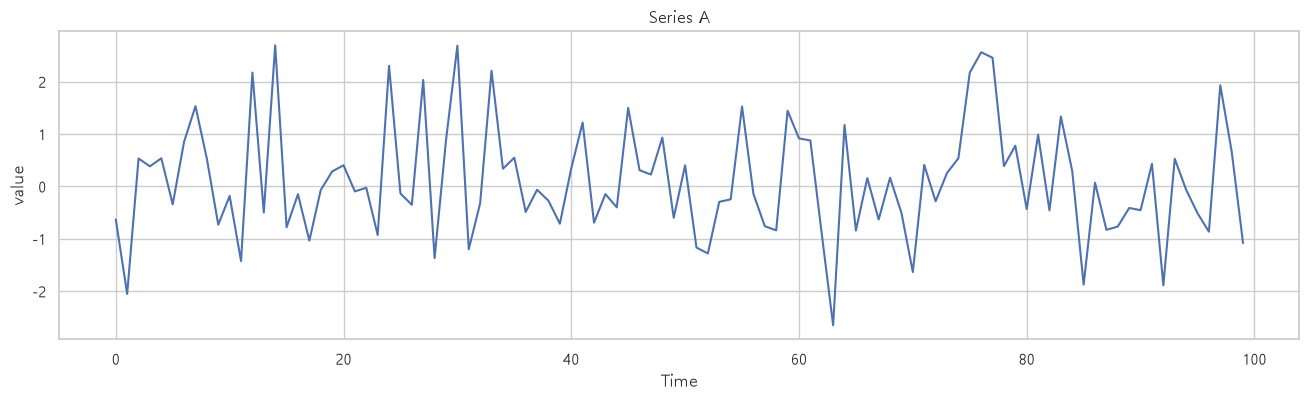

In [35]:
# 정규분포인가 확인하기
plt.plot(seriesA)
plt.xlabel('Time')
plt.ylabel('value')
plt.title('Series A')

In [36]:
# 비정상성 데이터 : SeriesB
## 시간에 따라 변화하는 매개변수 = t*0.1 = 즉 시간이 커질 수록 증가함
## 매개변수가 시간에 따라 변화한다 = params이 계속 바뀐다
T = 100 

seriesB = pd.Series(index=range(T), dtype=np.float64) #0~99
seriesB.name = 'seriesB'

# 값 채워주기 
for t in range(T):
    params = (t*0.1,1) # 평균을 t*0.1 즉 평균이 계속 증가함 
    seriesB[t] = generate_datapoint(params)

seriesB

0     -0.064402
1      1.491512
2      2.061032
3      1.400601
4      2.137466
        ...    
95    10.569517
96    10.271833
97     9.240632
98     9.506015
99     9.375415
Name: seriesB, Length: 100, dtype: float64

Text(0.5, 1.0, 'SeriesB')

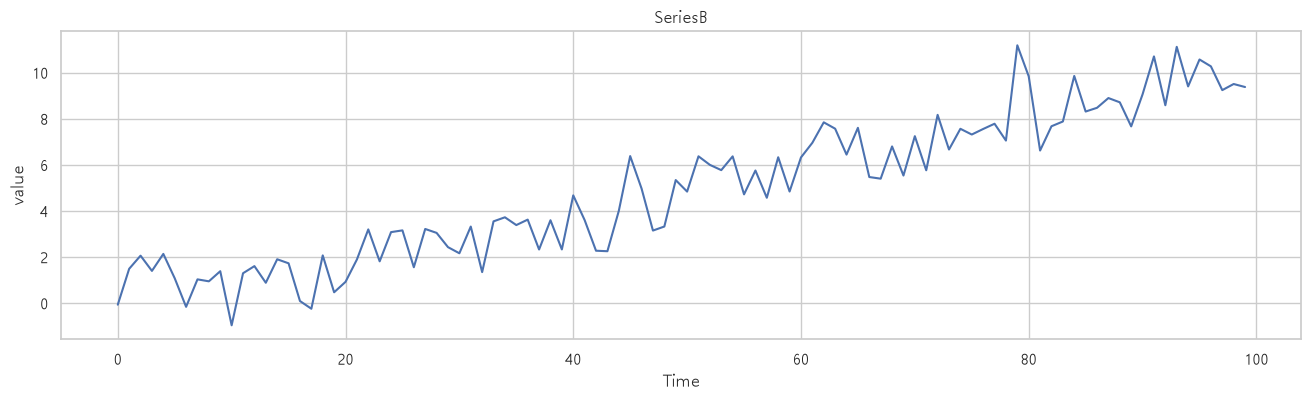

In [ ]:
# T에 따라서 평균값이 올라감 
plt.plot(seriesB)
plt.xlabel('Time')
plt.ylabel('value')
plt.title('SeriesB')

### 비정상성이 위험한 이유!

전체 평균에 비교해서 평균값이 어떻게 변화하는 지 비교하면 보임


Text(0.5, 1.0, 'SeriesB')

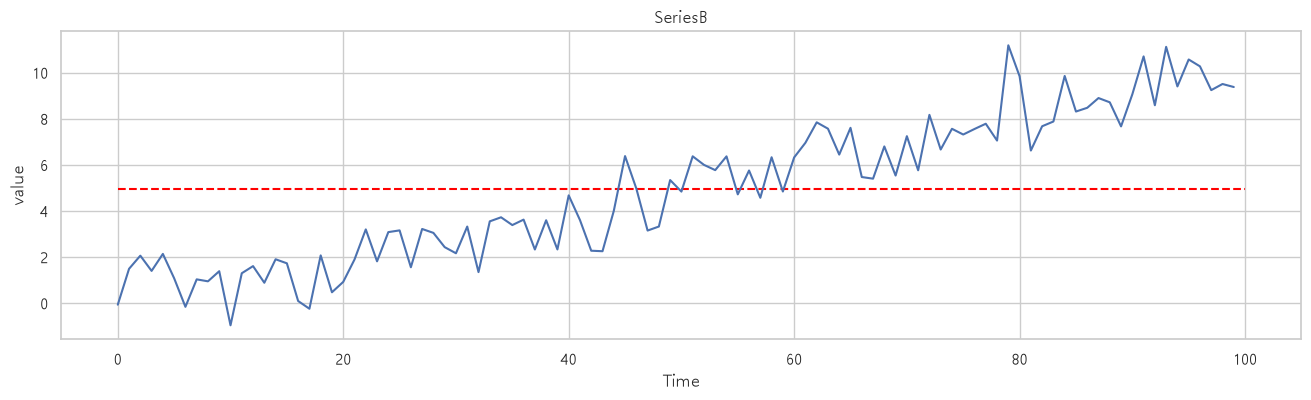

In [42]:
#시계열 전체 평균 M
m = np.mean(seriesB)

plt.hlines(m,0,len(seriesB),linestyles='dashed', color='red')
plt.plot(seriesB)
plt.xlabel('Time')
plt.ylabel('value')
plt.title('SeriesB')

# 전체 평균에 비해 평균이 자꾸 작고 커짐 = 분석이 어려워짐 

In [ ]:
# 정상성 adf로 확인하기 
check_for_stationarity(seriesA) # Stationary

p-value: 6.4226932885576255e-18, 해당 시리즈 seriesA은 정상성 시계열 데이터로 보임. 


True

In [44]:
check_for_stationarity(seriesB)

p-value: 0.9755579873722242, 해당 시리즈 seriesB은 비정상성 시계열 데이터로 보임.


False

#### Series C: 

- 시간이 지남에 따라 매개변수가 달라지는데 전체적으로는 주기함수를 가지는 데이터 포인트
- 표준편차는 동일하게 유지되는 
- 

Text(0.5, 1.0, 'seriesC')

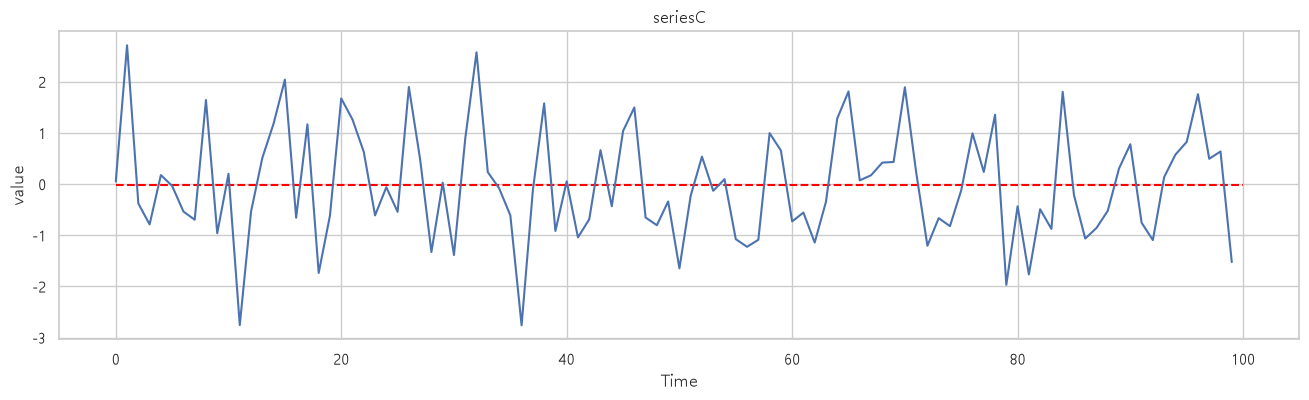

In [ ]:
T = 100 

seriesC = pd.Series(index=range(T), dtype=np.float64) #0~99
seriesC.name = 'seriesC'

for t in range(T):
    # 매개변수가 시간에 따라 달라지는데
    # SINE 함수를 기반으로 주기성을 가지게
    params = (np.sin(t),1)
    seriesC[t] = generate_datapoint(params)
    
    
m = np.mean(seriesC)

plt.hlines(m,0,len(seriesC),linestyles='dashed', color='red')
plt.plot(seriesC)
plt.xlabel('Time')
plt.ylabel('value')
plt.title('seriesC')

육안으로 보면 평균이 일정하고, 
